In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('TIMING.csv')

In [3]:
rot_fit_time = float(df[df['ID'] == 'rot_train___128_1e-05_0.5'].iloc[0]['time'])
rot_explain_time = float(df[df['ID'] == 'rot_explanation'].iloc[0]['time'])
rot_combined = float(df[df['ID'] == 'rot_combined'].iloc[0]['time'])

In [4]:
df_embedding = df[df['ID'] == 'embedding_generation']
df_shap = df[df['ID'] == 'shap']
df_ig = df[df['ID'] == 'ig']
# df_shap=df_shap.sort_values(by='time')

In [5]:
df_shap['cumm_time'] = df_shap['time'].cumsum()
df_shap['avg_time'] = 1
df_shap['avg_time'] = df_shap['cumm_time'] / df_shap['avg_time'].cumsum()
# df_shap.head()

/var/folders/5y/12pqhhcj1jl__kkv_31jm3g40000gn/T/ipykernel_66693/4099526920.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shap['cumm_time'] = df_shap['time'].cumsum()
/var/folders/5y/12pqhhcj1jl__kkv_31jm3g40000gn/T/ipykernel_66693/4099526920.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shap['avg_time'] = 1
/var/folders/5y/12pqhhcj1jl__kkv_31jm3g40000gn/T/ipykernel_66693/4099526920.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [6]:
df_shap['rot_cumm'] = rot_combined
df_shap['rot_cumm'] += np.linspace(0,rot_explain_time, len(df_shap)+1)[1:]
df_shap['rot_avg'] = 1
df_shap['rot_avg'] = df_shap['rot_avg'].cumsum()
df_shap['rot_avg'] = df_shap['rot_cumm'] / df_shap['rot_avg']

/var/folders/5y/12pqhhcj1jl__kkv_31jm3g40000gn/T/ipykernel_66693/1872925404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shap['rot_cumm'] = rot_combined
/var/folders/5y/12pqhhcj1jl__kkv_31jm3g40000gn/T/ipykernel_66693/1872925404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shap['rot_cumm'] += np.linspace(0,rot_explain_time, len(df_shap)+1)[1:]
/var/folders/5y/12pqhhcj1jl__kkv_31jm3g40000gn/T/ipykernel_66693/1872925404.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy o

In [7]:
df_shap['case_number'] = [i+1 for i in range(len(df_shap))]
df_ig['case_number'] = [i+1 for i in range(len(df_ig))]

/var/folders/5y/12pqhhcj1jl__kkv_31jm3g40000gn/T/ipykernel_66693/801090867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shap['case_number'] = [i+1 for i in range(len(df_shap))]
/var/folders/5y/12pqhhcj1jl__kkv_31jm3g40000gn/T/ipykernel_66693/801090867.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ig['case_number'] = [i+1 for i in range(len(df_ig))]


In [8]:
# df_shap

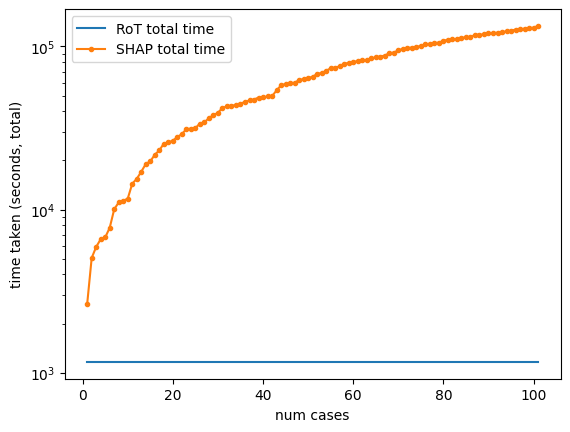

In [9]:
plt.plot(df_shap['case_number'], df_shap['rot_cumm'], label='RoT total time', marker=',')
plt.plot(df_shap['case_number'], df_shap['cumm_time'], label='SHAP total time', marker='.')
plt.xlabel('num cases')
plt.ylabel('time taken (seconds, total)')
plt.yscale('log')
plt.legend()


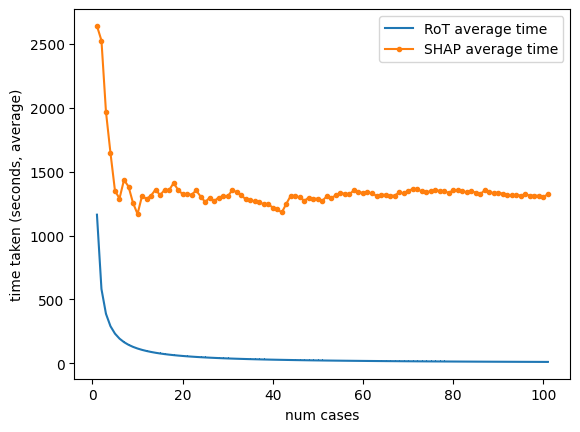

In [10]:
plt.plot(df_shap['case_number'], df_shap['rot_avg'], label='RoT average time', marker=',')
plt.plot(df_shap['case_number'], df_shap['avg_time'], label='SHAP average time', marker='.')
# plt.axhline(np.mean(df_shap['avg_time']), label='SHAP overall average', linestyle=':')
# plt.axhline(df_shap['rot_cumm'].values.tolist()[-1], label='RoT total', linestyle=':')
plt.xlabel('num cases')
plt.ylabel('time taken (seconds, average)')
plt.legend()


In [11]:
# df_shap.describe()

In [12]:
rot_times = [rot_explain_time / len(df_shap)] * len(df_shap)
rot_times[0] += rot_combined

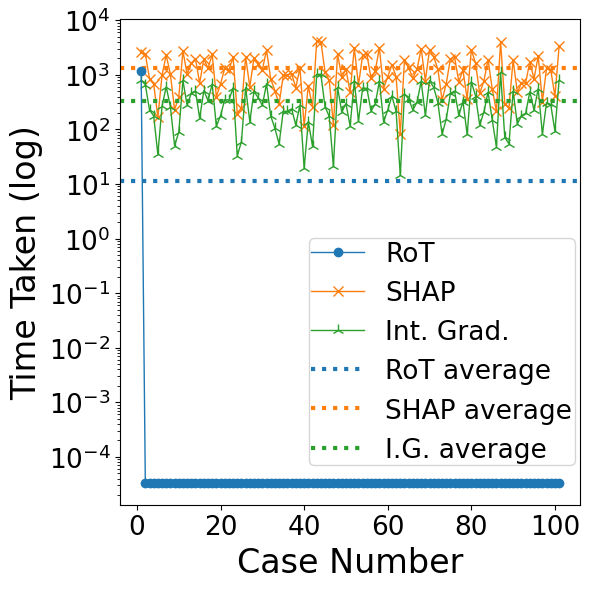

In [13]:
plt.figure(figsize=(6,6))
plt.plot(df_shap['case_number'], rot_times, label='RoT', marker='.', linewidth=1, ms=12, zorder=3)
plt.plot(df_shap['case_number'], df_shap['time'], label='SHAP', marker='x', linewidth=1, ms=7, zorder=1)
plt.plot(df_ig['case_number'], df_ig['time'], label='Int. Grad.', marker='2', linewidth=1, ms=9, zorder=2, color='C2')
plt.axhline(np.mean(rot_times), label='RoT average', linestyle=':', linewidth=3, zorder=1)
plt.axhline(np.mean(df_shap['time']), label='SHAP average', linestyle=':', color='tab:orange', linewidth=3, zorder=2)
plt.axhline(np.mean(df_ig['time']), label='I.G. average', linestyle=':', color='C2', linewidth=3, zorder=2)
# plt.axhline(df_shap['rot_cumm'].values.tolist()[-1], label='RoT total', linestyle=':')
plt.xlabel('Case Number', fontsize=24)
plt.ylabel('Time Taken (log)', fontsize=24)
# plt.title('RoT vs SHAP: Time to Compute Explanations')
# plt.yscale('symlog')
# plt.ylim(0,8000)
plt.yticks(fontsize=19)
plt.xticks(fontsize=19)
plt.yscale('log')
plt.legend(fontsize=19, borderpad=0.1, borderaxespad=0.2, loc="lower right", bbox_to_anchor=(1,0.07))
plt.tight_layout()
plt.savefig('unsorted_runtimes.pdf', dpi=300)